In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils.sigma_estimation import estimate_diffusion_unprocessed

#### Loading AAPL data

/tmp/ipykernel_52137/484583999.py:27: DtypeWarning: Columns (1,2,4,5,6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_options = pd.read_csv(
/tmp/ipykernel_52137/484583999.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_options['mid_price'] = df_options['mid_price'].bfill()


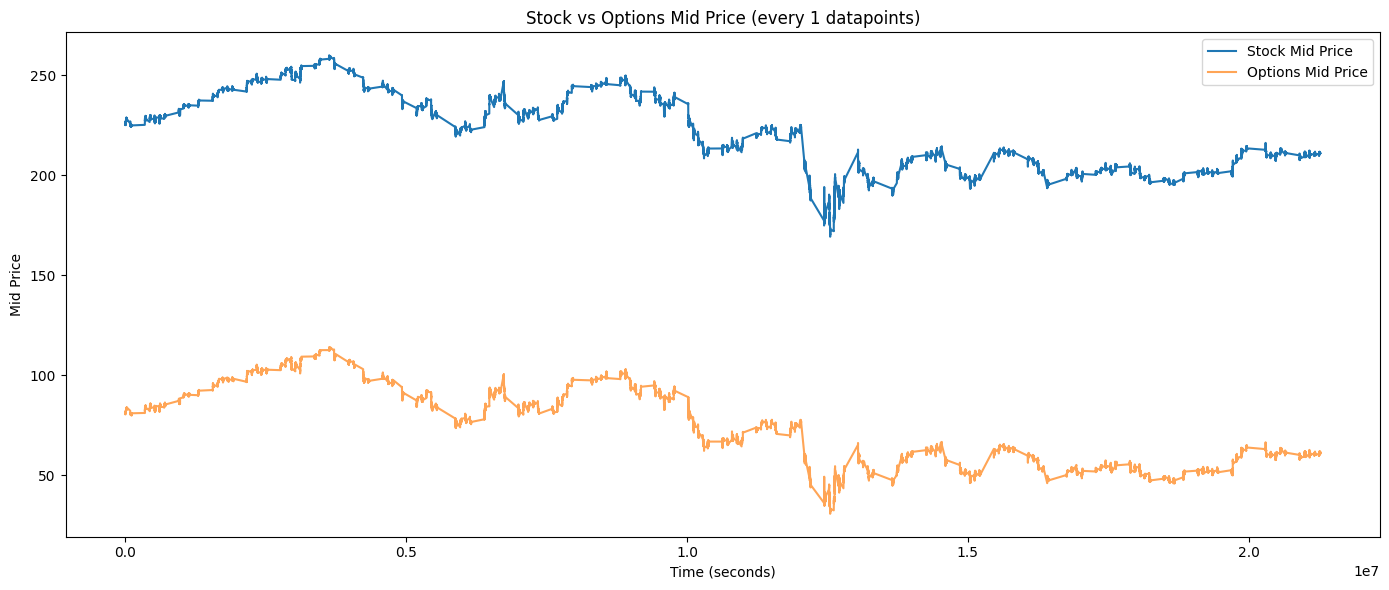

In [2]:
# Helper to safely convert numeric values
def to_float(x):
    try:
        return float(x)
    except ValueError:
        return None

# --- Load stock data ---
df_stock = pd.read_csv(
    "../../data/AAPL/aapl_stock.csv",
    converters={'bid': to_float, 'ask': to_float},
    dtype={'date': str, 'ms_of_day': str}  # ensure datetime strings
)

# Combine date + time into datetime column
df_stock['datetime'] = pd.to_datetime(
    df_stock['date'] + ' ' + df_stock['ms_of_day'], errors='coerce'
)

# Keep only valid rows
df_stock = df_stock.dropna(subset=['datetime', 'bid', 'ask'])
df_stock['mid_price'] = (df_stock['bid'] + df_stock['ask']) / 2
df_stock['mid_price'] = df_stock['mid_price'].replace(0, pd.NA)
df_stock['mid_price'] = df_stock['mid_price'].bfill()

# --- Load options data ---
df_options = pd.read_csv(
    "../../data/AAPL/aapl_options.csv",
    converters={'bid': to_float, 'ask': to_float},
    dtype={'date': str, 'ms_of_day': str}
)
df_options['datetime'] = pd.to_datetime(
    df_options['date'] + ' ' + df_options['ms_of_day'], errors='coerce'
)
df_options = df_options.dropna(subset=['datetime', 'bid', 'ask'])
df_options['mid_price'] = (df_options['bid'] + df_options['ask']) / 2
df_options['mid_price'] = df_options['mid_price'].replace(0, pd.NA)
df_options['mid_price'] = df_options['mid_price'].bfill()

# --- Align stock and options on datetime (nearest) ---
df_merged = pd.merge_asof(
    df_stock.sort_values("datetime"),
    df_options.sort_values("datetime")[["datetime", "mid_price"]],
    on="datetime",
    direction="nearest",
    suffixes=("_stock", "_options")
)

# --- Convert to numpy arrays with downsampling ---
def get_paths(df, skip=1):
    # Time in seconds from start
    t_path = (df["datetime"] - df["datetime"].iloc[0]).dt.total_seconds().to_numpy()
    S_path = df["mid_price_stock"].to_numpy()
    u_path = df["mid_price_options"].to_numpy()
    
    # Downsample (keep every skip-th point)
    return t_path[::skip], S_path[::skip], u_path[::skip]

# Example usage
skip = 1  # keep one point every 10 datapoints
t_path, S_path, u_path = get_paths(df_merged, skip=skip)

# --- Optional: Plot (just for visualization) ---
plt.figure(figsize=(14,6))
plt.plot(t_path, S_path, label="Stock Mid Price")
plt.plot(t_path, u_path, label="Options Mid Price", alpha=0.7)
plt.xlabel("Time (seconds)")
plt.ylabel("Mid Price")
plt.title(f"Stock vs Options Mid Price (every {skip} datapoints)")
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
print(df_merged['datetime'])

0         2024-11-14 09:30:00
1         2024-11-14 09:30:01
2         2024-11-14 09:30:02
3         2024-11-14 09:30:03
4         2024-11-14 09:30:04
                  ...        
3907962   2025-07-18 15:59:56
3907963   2025-07-18 15:59:57
3907964   2025-07-18 15:59:58
3907965   2025-07-18 15:59:59
3907966   2025-07-18 16:00:00
Name: datetime, Length: 3907967, dtype: datetime64[ns]


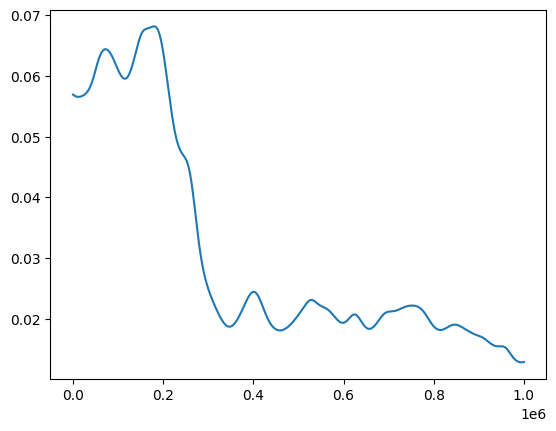

In [3]:
sigma_vals = estimate_diffusion_unprocessed(S_path, t_path, time_threshold=skip, n_grid=1_000_000)
plt.figure(figsize=(14,6))
plt.plot(t_path, sigma_vals)

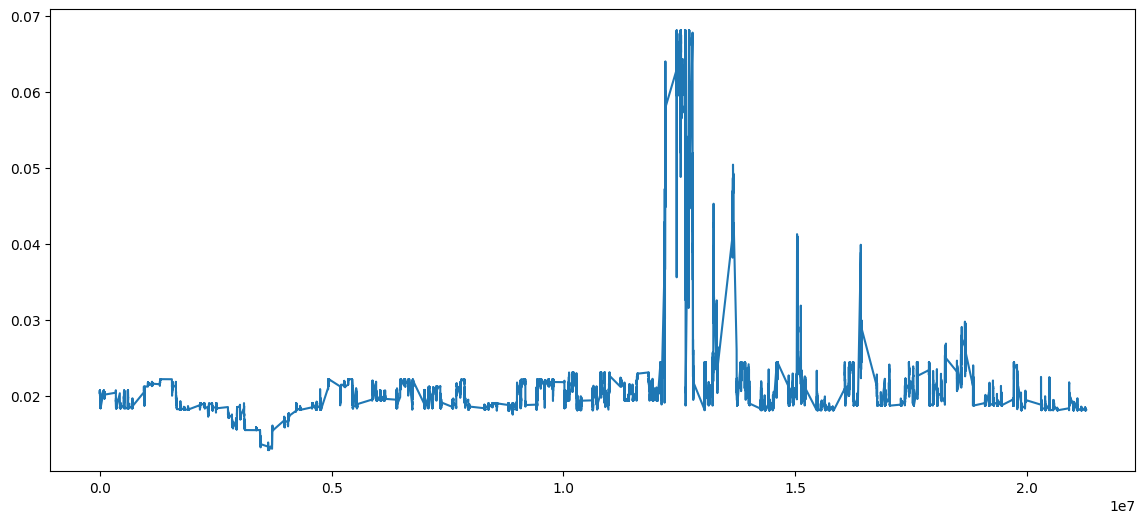

In [6]:

def extract_brownian_XD(assumed_r, S_path, sigma_estimate, dt):
    drift_term = assumed_r * S_path[:-1] * dt

    recovered_dB = (np.diff(S_path) - drift_term) / (sigma_estimate[:-1] * S_path[:-1])

    return recovered_dB

#### Verifying FFT estimation correctness

In [2]:
from src.utils.sigma_estimation import estimate_diffusion_fft

In [19]:
def black_scholes_solution_vectorized(s_array, K, T_to_maturity, r, sigma_val):
    """Analytical solution for European call option price."""
    tau = np.maximum(T_to_maturity, 1e-9)
    d1 = (np.log(s_array / K) + (r + 0.5 * sigma_val ** 2) * tau) / (sigma_val * np.sqrt(tau))
    d2 = d1 - sigma_val * np.sqrt(tau)
    call_price = s_array * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    # At maturity (T_to_maturity <= 0), the price is the payoff
    return np.where(T_to_maturity <= 0, np.maximum(s_array - K, 0), call_price).astype(np.float64)

def sigma_func(X):
    return np.sqrt(X)

T = 1
N_SIM = 1_000_000
R = 0.1
K = 102

dt = T / N_SIM
t_path = np.linspace(0, T, N_SIM, dtype=np.float64)

# Initialize stock price path
s_path = np.zeros(N_SIM, dtype=np.float64)
s_path[0] = 100

# Generate path using Euler-Maruyama for Geometric Brownian Motion
db_path = np.random.normal(0, np.sqrt(dt), size=(N_SIM - 1))
for i in range(N_SIM - 1):
    s_path[i + 1] = s_path[i] + R * s_path[i] * dt + sigma_func(s_path[i]) * db_path[i]

# Calculate option price path using the analytical Black-Scholes solution
# u_path = black_scholes_solution_vectorized(s_path, K, cfg.T - t_path, cfg.R, cfg.SIGMA_VAL)

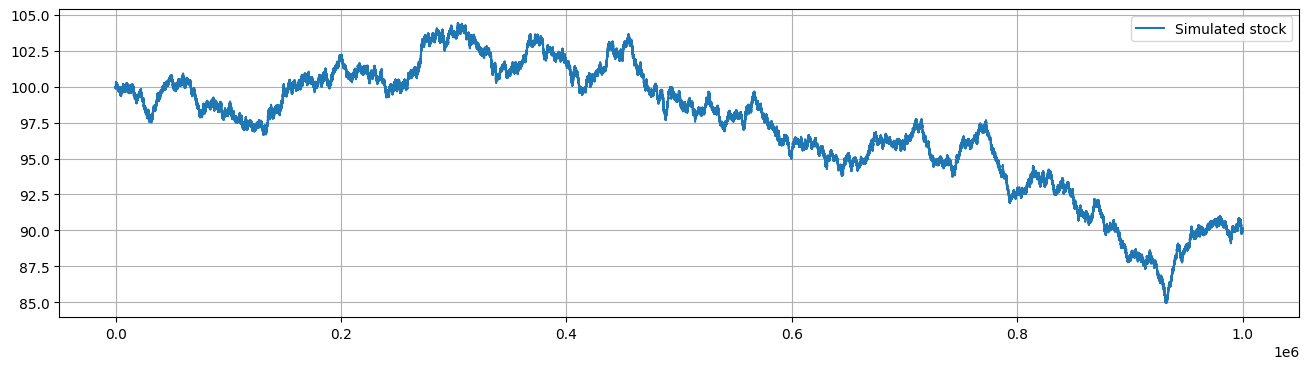

In [20]:
plt.figure(figsize=(16,4))
plt.plot(s_path, label="Simulated stock")
plt.grid()
plt.legend()
plt.show()

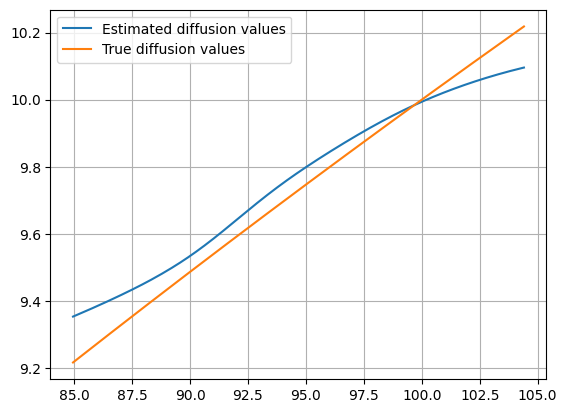

In [21]:
s_grid, sigma_vals = estimate_diffusion_fft(s_path[:-1], (np.diff(s_path) ** 2) / dt, bandwidth=2.5)

plt.plot(s_grid, sigma_vals, label="Estimated diffusion values")
plt.plot(s_grid, sigma_func(s_grid), label="True diffusion values")
plt.grid()
plt.legend()
plt.show()

Plotting the stock path with gaps...


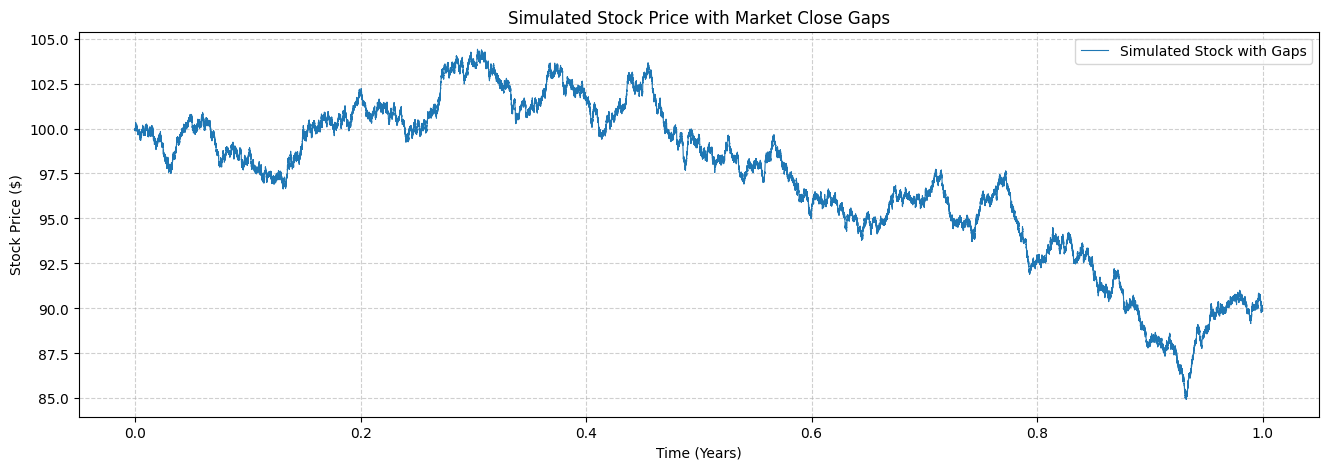

In [22]:
STEPS_PER_TRADING_DAY = 100 
STEPS_PER_GAP = 50

# Introduce Gaps into the Data
total_period = STEPS_PER_TRADING_DAY + STEPS_PER_GAP
num_periods = N_SIM // total_period

indices_to_keep = []
for i in range(num_periods):
    start_index = i * total_period
    end_index = start_index + STEPS_PER_TRADING_DAY
    indices_to_keep.extend(range(start_index, end_index))


s_path_gappy = s_path[indices_to_keep]
t_path_gappy = t_path[indices_to_keep]


print("Plotting the stock path with gaps...")
plt.figure(figsize=(16, 5))
plt.plot(t_path_gappy, s_path_gappy, label="Simulated Stock with Gaps", linewidth=0.8)
plt.title("Simulated Stock Price with Market Close Gaps")
plt.xlabel("Time (Years)")
plt.ylabel("Stock Price ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

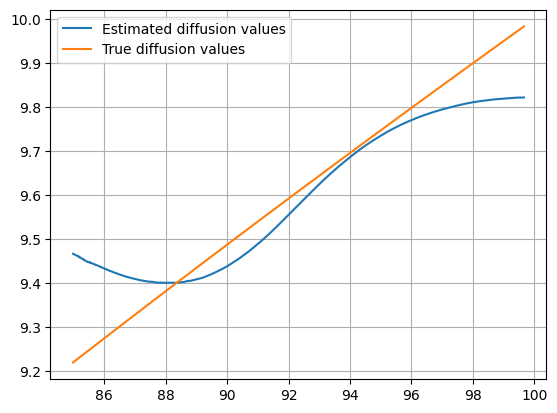

In [23]:
time_threshold = min(np.diff(t_path_gappy))
s_grid, sigma_on_grid, sigma_vals = estimate_diffusion_unprocessed(s_path_gappy, t_path_gappy, time_threshold=time_threshold)

plt.plot(s_grid, sigma_on_grid, label="Estimated diffusion values")
plt.plot(s_grid, sigma_func(s_grid), label="True diffusion values")
plt.grid()
plt.legend()
plt.show()

In [164]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "font.size": 20,         # base font size for all text
    "axes.titlesize": 24,    # title font size
    "axes.labelsize": 22,    # x/y labels
    "legend.fontsize": 18,   # legend text
    "xtick.labelsize": 18,   # x tick labels
    "ytick.labelsize": 18,    # y tick labels
    
    # Font
    "text.usetex": False,
    "font.family": "sans-serif",   # Matplotlib default
    "font.serif": [],
})

In [165]:
calculate_intervals = True
confidence_level = 0.99

def save_results_plot(t_path, true_u_path, predicted_u_path, lower_path, upper_path, zoom_start_t, zoom_end_t,
                      zoom_pos, num_unhidden):
    """Saves a publication-ready plot comparing ground truth and prediction, with a zoom-in inset."""

    # save_dir = Path("models") / Path("AAPL_ten")
    # save_dir.mkdir(exist_ok=True)
    save_path = Path("../../plot_temp") / "bs_pred.png"

    # --- Main Plot Setup ---
    fig, ax = plt.subplots(figsize=(15, 8))

    # Plot the full ground truth path
    ax.plot(t_path[num_unhidden - 1:], true_u_path[num_unhidden - 1:], label='Ground Truth',
            color='black', linewidth=2, zorder=2)

    # Plot the newly predicted points with a thinner line
    ax.plot(t_path[num_unhidden - 1:], predicted_u_path[num_unhidden - 1:],
            label='Prediction (Online)', color='red', linestyle='--', linewidth=2.0, zorder=3)

    # Plot the confidence interval as a shaded region
    if calculate_intervals:
        ax.fill_between(
            t_path[num_unhidden - 1:],
            lower_path[num_unhidden - 1:],
            upper_path[num_unhidden - 1:],
            color='red',
            alpha=0.2,
            label=f'{int(confidence_level * 100)}% Confidence Interval'
        )

    # Add a vertical line to mark where the prediction begins
    ax.axvline(x=t_path[num_unhidden - 1], color='gray', linestyle=':',
               label='Prediction Start', zorder=1)

    # --- Inset Plot (Zoom-in) ---
    # Position: [left, bottom, width, height] -> moved to bottom right
    axins = ax.inset_axes(zoom_pos)

    # Create masks to select data for the zoom
    valid_range_mask = t_path >= t_path[num_unhidden - 1]
    zoom_mask = (t_path >= zoom_start_t) & (t_path <= zoom_end_t) & valid_range_mask

    # If the default zoom region has no data, create a new one from the last 100 points
    if not np.any(zoom_mask):
        end_index = len(t_path)
        start_index = max(num_unhidden - 1, end_index - 100)

        zoom_mask = np.zeros_like(t_path, dtype=bool)
        zoom_mask[start_index:end_index] = True

        zoom_start_t = t_path[start_index]
        zoom_end_t = t_path[end_index - 1]

    # Plot the same data but for the zoomed region on the inset axes
    axins.plot(t_path[zoom_mask], true_u_path[zoom_mask], color='black', linewidth=1.5)
    axins.plot(t_path[zoom_mask], predicted_u_path[zoom_mask], color='red', linestyle='--', linewidth=2.0)
    if calculate_intervals:
        axins.fill_between(t_path[zoom_mask], lower_path[zoom_mask], upper_path[zoom_mask],
                           color='red', alpha=0.2)

    # Set the limits and labels for the inset plot
    axins.set_xlim(zoom_start_t, zoom_end_t)
    axins.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, prune='both'))
    y_min_inset = min(np.min(lower_path[zoom_mask]), np.min(true_u_path[zoom_mask]))
    y_max_inset = max(np.max(upper_path[zoom_mask]), np.max(true_u_path[zoom_mask]))
    y_padding = (y_max_inset - y_min_inset) * 0.1
    axins.set_ylim(y_min_inset - y_padding, y_max_inset + y_padding)
    axins.set_title(f"Zoom in (t={zoom_start_t:.4f}-{zoom_end_t:.4f})")
    axins.grid(True, linestyle=':')

    # Draw a box indicating the zoom area on the main plot
    ax.indicate_inset_zoom(axins, edgecolor="black")

    # --- Final Touches for Main Plot ---
    ax.set_xlabel('Time (t)')
    ax.set_ylabel('Option Price (u)')
    ax.legend(loc='upper left', prop={'weight':'bold'})
    ax.grid(True, linestyle=':')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

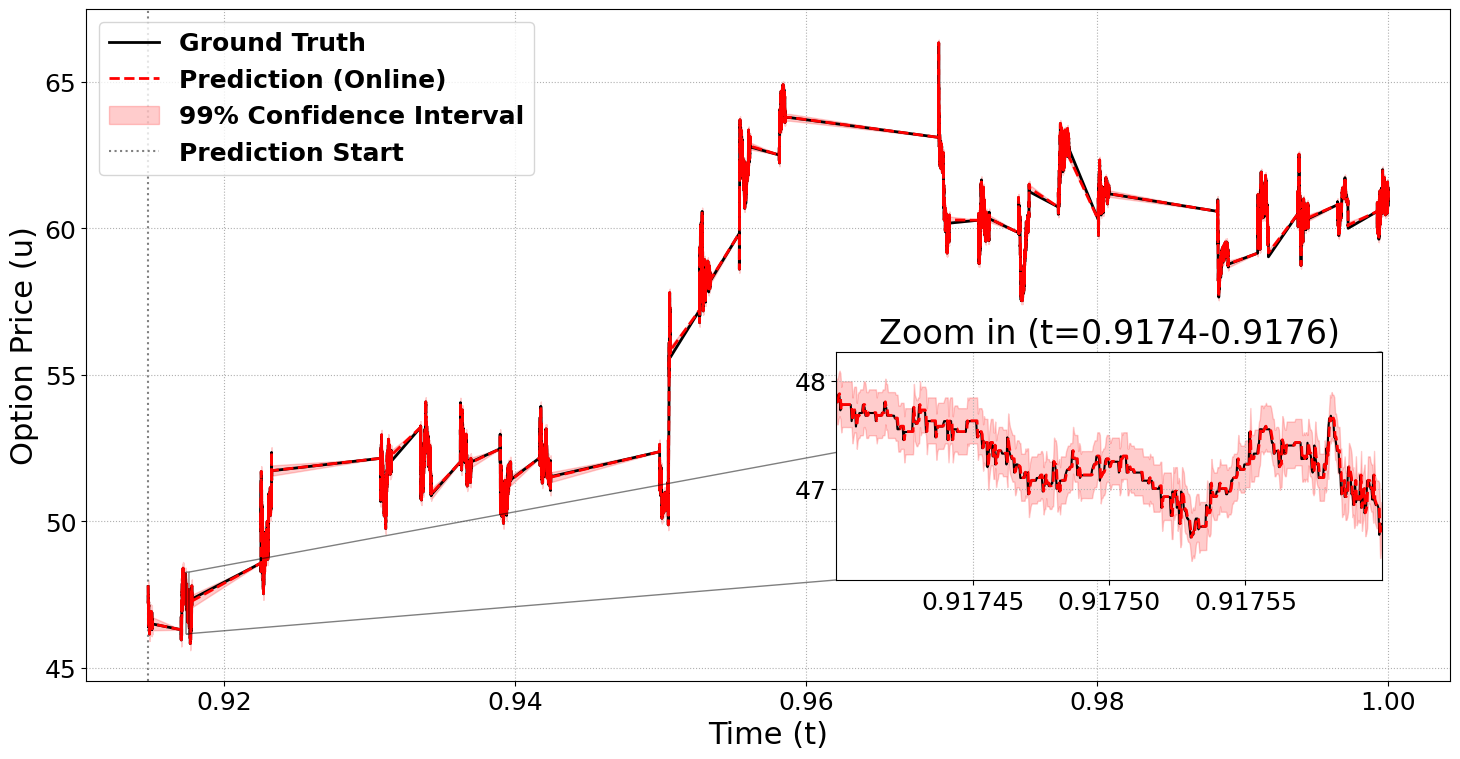

In [135]:
# 1. Define the exact same path to your saved file
filepath = "prediction_outputs_real.npz"

# 2. Load the .npz file
loaded_data = np.load(filepath)

# 3. Access each array by the key you used when saving
t_loaded_real = loaded_data['t']
u_true_loaded_real = loaded_data['u_true']
u_pred_loaded_real = loaded_data['predictions']
lb_loaded_real = loaded_data['lower_bounds']
ub_loaded_real = loaded_data['upper_bounds']

save_results_plot(t_loaded_real, u_true_loaded_real, u_pred_loaded_real, lb_loaded_real, ub_loaded_real, zoom_pos=[0.55, 0.15, 0.4, 0.34], zoom_start_t=0.9174, zoom_end_t=0.9176, num_unhidden=250_000)

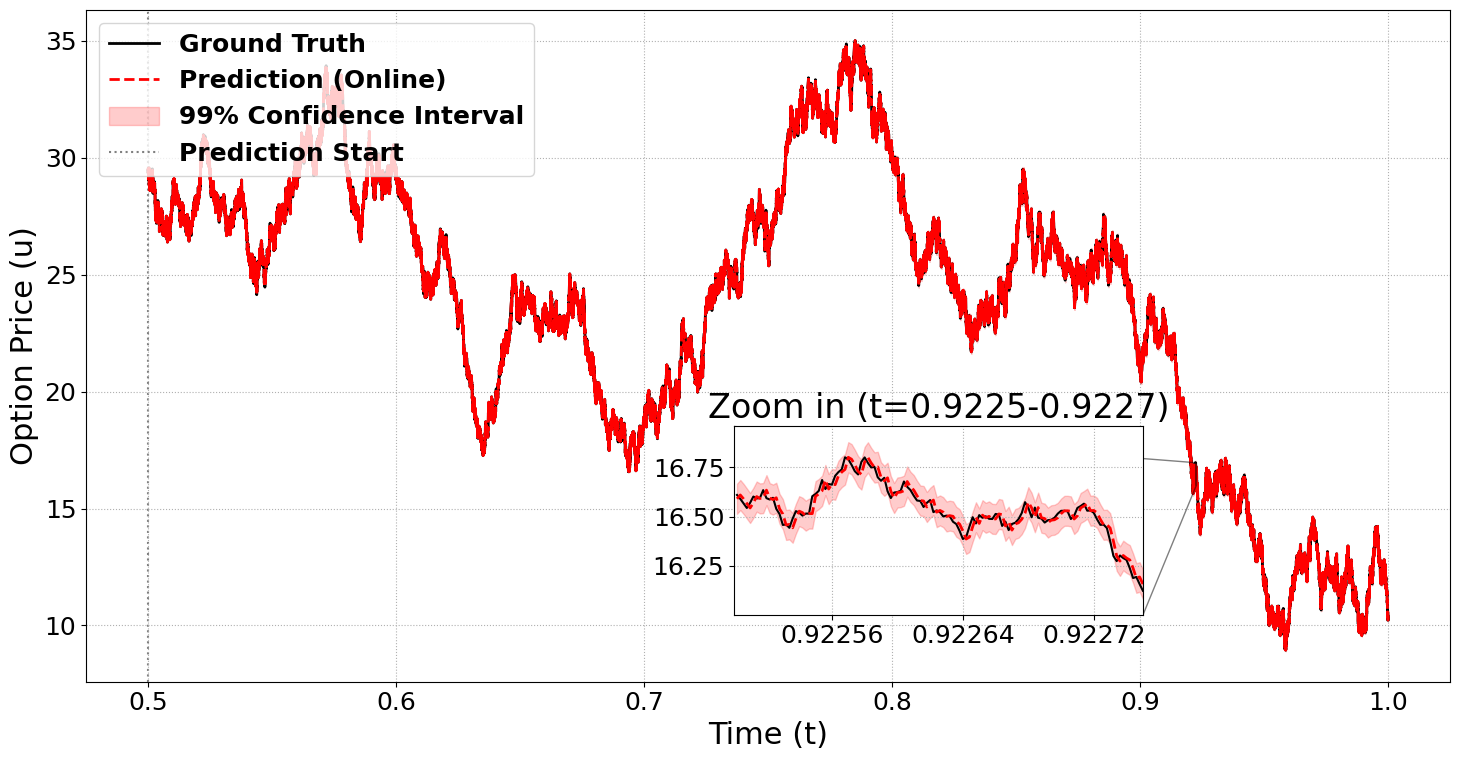

In [166]:
# 1. Define the exact same path to your saved file
filepath = "prediction_outputs_bs.npz"

# 2. Load the .npz file
loaded_data = np.load(filepath)

# 3. Access each array by the key you used when saving
t_loaded_bs = loaded_data['t']
u_true_loaded_bs = loaded_data['u_true']
u_pred_loaded_bs = loaded_data['predictions']
lb_loaded_bs = loaded_data['lower_bounds']
ub_loaded_bs = loaded_data['upper_bounds']

save_results_plot(t_loaded_bs, u_true_loaded_bs, u_pred_loaded_bs, lb_loaded_bs, ub_loaded_bs, zoom_pos=[0.475, 0.1, 0.3, 0.28], zoom_start_t=0.9225, zoom_end_t=0.92275, num_unhidden=250_000)

In [182]:
def _plot_generated_paths(t_history, s_history, u_history, time_generated, options_generated, stocks_generated):
    """Saves a plot showing historical data and generated future paths for both stock and options."""

    # --- 1. Set up the figure and subplots ---
    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16), sharex=True)
    fig, ax2 = plt.subplots(1, 1, figsize=(15, 8), sharex=True)

    # --- 2. Limit the amount of history shown ---
    num_generated_steps = options_generated.shape[1]
    history_to_show = min(len(t_history), int(0.7 * num_generated_steps))
    hist_start_idx = len(t_history) - history_to_show

    time_hist_sliced = t_history[hist_start_idx:]
    stock_hist_sliced = s_history[hist_start_idx:]
    option_hist_sliced = u_history[hist_start_idx:]

    # --- 3. Plot the known historical paths ---
    # ax1.plot(time_hist_sliced, stock_hist_sliced, label='Historical Path', color='black', linewidth=3, zorder=5)
    ax2.plot(time_hist_sliced, option_hist_sliced, label='Historical Path', color='black', linewidth=3, zorder=5)

    # --- 4. Plot all the generated future paths with paired coloring ---
    num_to_plot = min(500, options_generated.shape[0])  # Limit plotted paths for clarity

    # Use a colormap to generate distinct colors for each path
    colors = plt.cm.viridis(np.linspace(0, 1, num_to_plot))

    for i in range(num_to_plot):
        label = 'Generated Paths' if i == 0 else None  # Add a single legend entry

        # Use the same color for the corresponding stock and option path
        path_color = colors[i]

        # ax1.plot(time_generated, stocks_generated[i, :], color=path_color, alpha=0.6, linewidth=1.5, label=label)
        ax2.plot(time_generated, options_generated[i, :], color=path_color, alpha=0.6, linewidth=1.5, 
              label=label)

    # --- 5. Add vertical lines to mark where the simulation begins ---
    simulation_start_time = t_history[-1]
    # ax1.axvline(x=simulation_start_time, color='gray', linestyle=':', linewidth=2, label='Simulation Start',
    #            zorder=4)
    ax2.axvline(x=simulation_start_time, color='gray', linestyle=':', linewidth=2, label='Simulation Start')

    # --- 6. Finalize plot aesthetics ---
    # ax1.set_xlabel('Time (t)')
    # ax1.set_ylabel('Stock Price')
    # ax1.legend(prop={'weight':'bold'})
    # ax1.grid(True, linestyle=':')

    ax2.set_xlabel('Time (t)')
    ax2.set_ylabel('Option Price')
    # The legend from the first plot is sufficient
    ax2.legend(prop={'weight':'bold'})
    ax2.grid(True, linestyle=':')

    plt.tight_layout()
    plt.savefig(Path("../../plot_temp") / "option_gen.png", dpi=300, bbox_inches="tight")
    plt.show()

In [183]:
# 1. Define the exact same path to your saved file
filepath = "generated_paths_data.npz"

# 2. Load the .npz file
loaded_data = np.load(filepath)

# 3. Access each array by the key you used when saving
time_generated = loaded_data['time_generated']
options_generated = loaded_data['options_generated']
stocks_generated = loaded_data['stocks_generated']
t_history = loaded_data['time_hist_sliced']
s_history = loaded_data['stock_hist_sliced']
u_history = loaded_data['option_hist_sliced']
simulation_start_time = loaded_data['simulation_start_time']

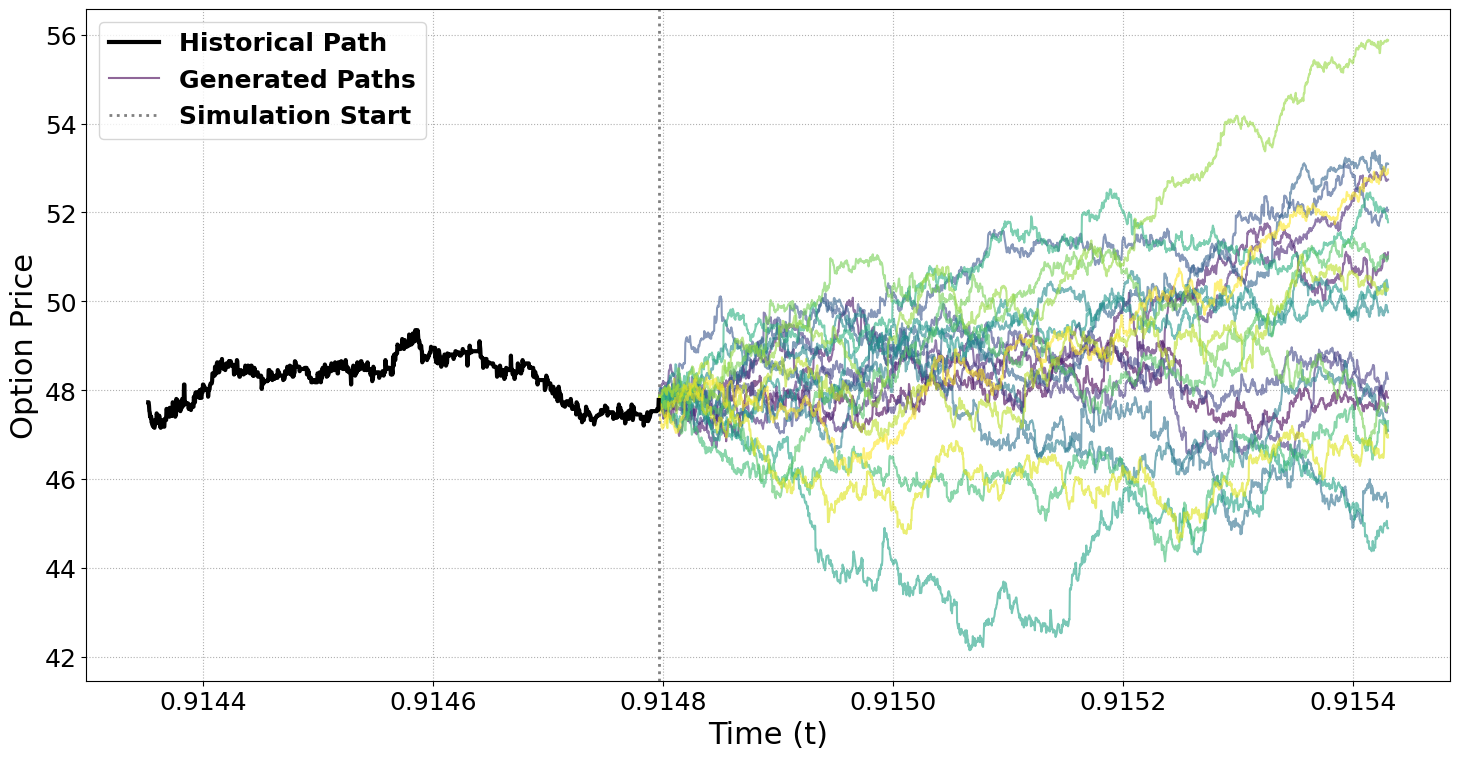

In [184]:
_plot_generated_paths(t_history, s_history, u_history, time_generated[:2000], options_generated[:, :2000], stocks_generated[:, :2000])

In [176]:
def _check_derivatives(u_t_pred, u_S_pred, u_SS_pred, actual_theta, actual_gamma, actual_delta, t_train):
    """ Compare derivatives of model and analytic derivatives on a plot """

    fig, axs = plt.subplots(figsize=(15, 8), sharex=True)

    plot_data = [
        # ("u_t (Theta)", actual_theta, u_t_pred),
        ("$u_s$ (Delta $\Delta$)", actual_delta, u_S_pred),
        # ("u_SS (Gamma)", actual_gamma, u_SS_pred)
    ]

    for i, (title, truth, pred) in enumerate(plot_data):
        axs.plot(t_train, truth, label="Ground Truth (Analytical)", color='black', linestyle='--')
        axs.plot(t_train, pred, label="Model Prediction", color='red', alpha=0.7)
        # axs.set_title(title)
        axs.grid(True, linestyle=':')
        axs.legend(prop={'weight':'bold'})

    plt.ylabel("(Delta) $\Delta$")
    plt.xlabel("Time (t)")
    plt.tight_layout()

    save_path = Path("../../plot_temp") / "derivatives.png"
    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_112557/3616973890.py:8: SyntaxWarning: invalid escape sequence '\D'
  ("$u_s$ (Delta $\Delta$)", actual_delta, u_S_pred),
/tmp/ipykernel_112557/3616973890.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("(Delta) $\Delta$")


In [177]:
# 1. Define the exact same path to your saved file
filepath = "derivatives.npz"

# 2. Load the .npz file
loaded_data = np.load(filepath)

u_t_pred=loaded_data['u_t_pred']
u_s_pred=loaded_data['u_s_pred']
u_ss_pred=loaded_data['u_ss_pred']
actual_theta=loaded_data['actual_theta']
actual_delta=loaded_data['actual_delta']
actual_gamma=loaded_data['actual_gamma']
t_train=loaded_data['t_train']

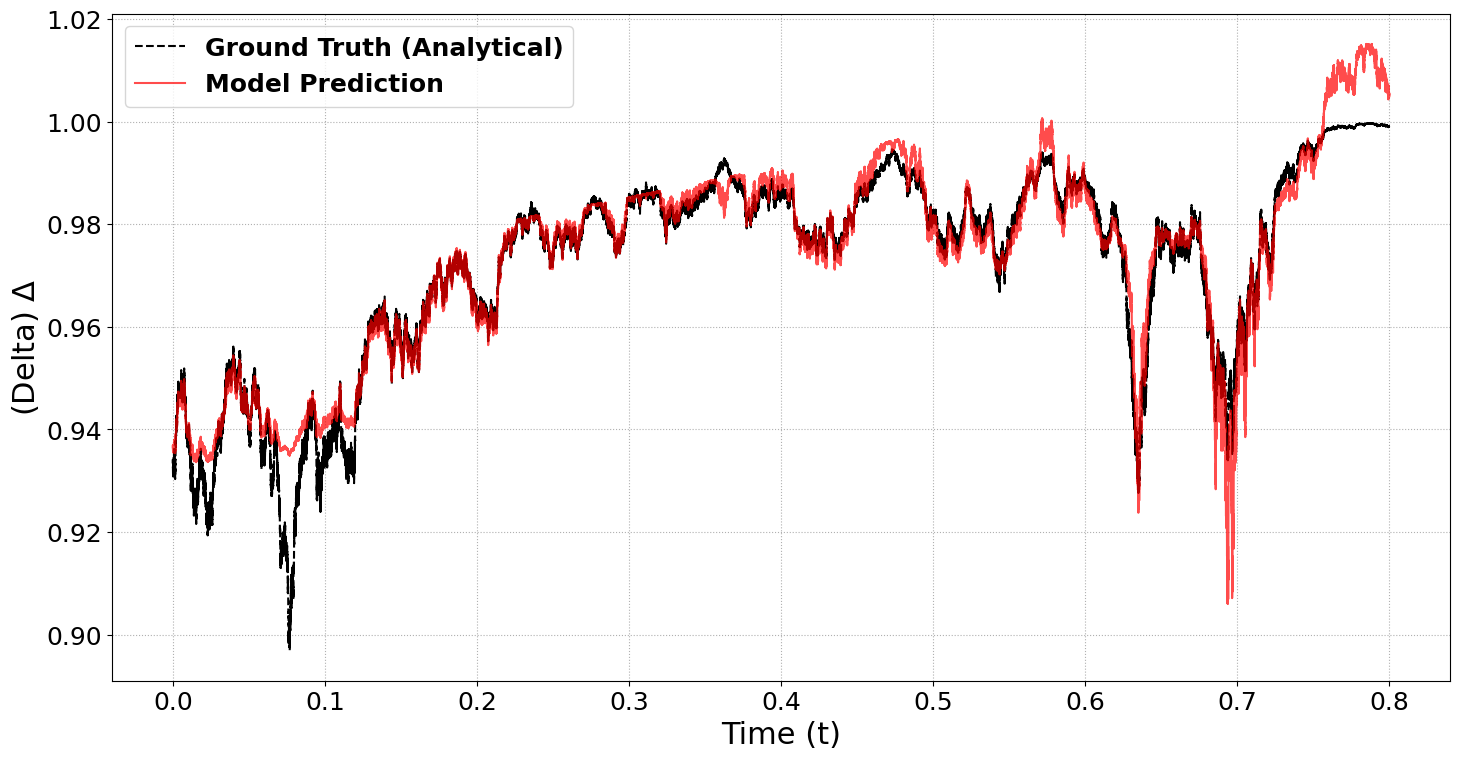

In [178]:
_check_derivatives(u_t_pred, u_s_pred, u_ss_pred, actual_theta, actual_gamma, actual_delta, t_train)

Final Euler Price: 42.9175
Final Exact Price: 41.3001
Max Discrepancy:   1.9567


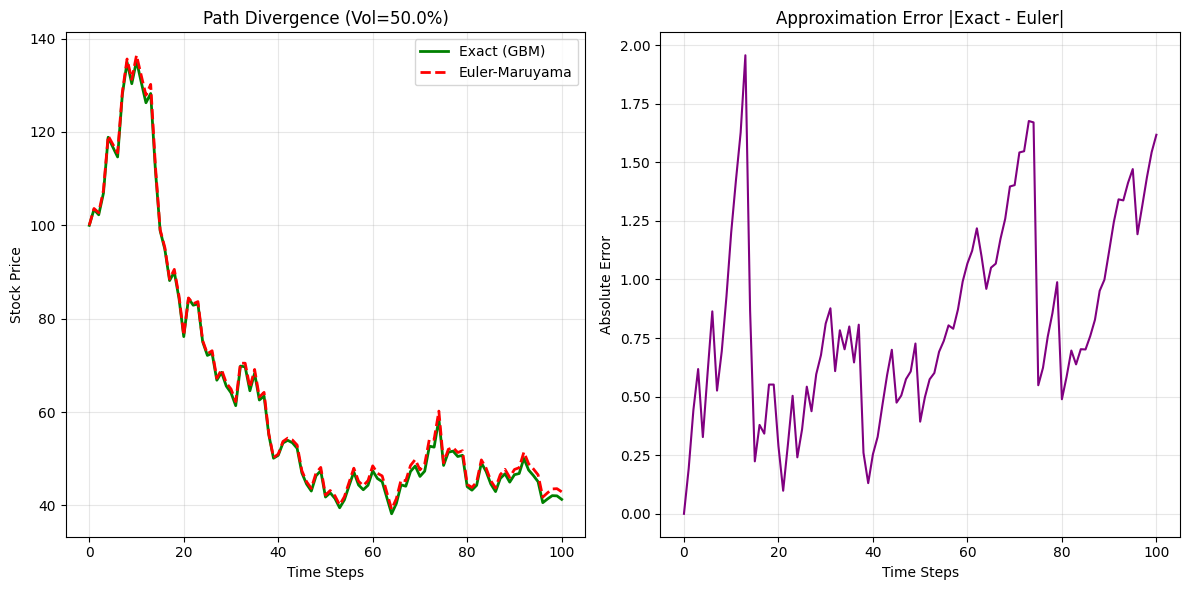

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup Parameters ---
# We use a larger Sigma and T to make the divergence obvious visually
S0 = 100.0
T = 2.0
R = 0.05
SIGMA = 0.5  # High volatility emphasizes the "convexity" error
N_SIM = 100  # Relatively coarse steps to highlight the error
dt = T / N_SIM

# --- 2. Generate Common Randomness ---
np.random.seed(42)
# Brownian increments (dW)
db = np.random.normal(0, np.sqrt(dt), size=N_SIM)

# --- 3. Calculate Paths ---

# Method A: Euler-Maruyama (Current implementation)
s_euler = np.zeros(N_SIM + 1)
s_euler[0] = S0
for i in range(N_SIM):
    # S_{t+1} = S_t + S_t * (drift + diffusion)
    s_euler[i+1] = s_euler[i] + s_euler[i] * (R * dt + SIGMA * db[i])

# Method B: Exact Geometric Brownian Motion (Proposed)
# S_t = S_0 * exp( (mu - 0.5*sigma^2)*t + sigma*W_t )
drift_correction = (R - 0.5 * SIGMA**2) * dt
log_returns = drift_correction + SIGMA * db
# Cumulative sum gives us the total exponent at each step
cumulative_log_returns = np.cumsum(np.concatenate([[0], log_returns]))
s_exact = S0 * np.exp(cumulative_log_returns)

# --- 4. Analysis & Visualization ---

error = np.abs(s_exact - s_euler)
max_error = np.max(error)

print(f"Final Euler Price: {s_euler[-1]:.4f}")
print(f"Final Exact Price: {s_exact[-1]:.4f}")
print(f"Max Discrepancy:   {max_error:.4f}")

plt.figure(figsize=(12, 6))

# Subplot 1: The Paths
plt.subplot(1, 2, 1)
plt.plot(s_exact, label='Exact (GBM)', color='green', linewidth=2)
plt.plot(s_euler, label='Euler-Maruyama', color='red', linestyle='--', linewidth=2)
plt.title(f"Path Divergence (Vol={SIGMA*100}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")

# Subplot 2: The Error
plt.subplot(1, 2, 2)
plt.plot(error, color='purple')
plt.title("Approximation Error |Exact - Euler|")
plt.xlabel("Time Steps")
plt.ylabel("Absolute Error")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("xd")